<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/2_diagnostico/diagnos_prueba_inicial_pivu/49_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Button to open this notebook in Google Colab, featuring the Colab logo and the text Open In Colab."></a>
  </td>
</table>

In [3]:
import qrcode
from IPython.display import display
from PIL import Image

def generar_qr(url, version=1, box_size=4, border=4, fill_color="black", back_color="white"):
    """
    Genera y muestra un código QR para una URL dada en un Jupyter Notebook.
    
    Parámetros:
    - url: La URL para la cual generar el código QR
    - version: Tamaño del QR (1-40, donde 1 es el más pequeño)
    - box_size: Número de píxeles por cada "caja" del QR
    - border: Grosor del borde blanco alrededor del QR (en cajas)
    - fill_color: Color del código QR
    - back_color: Color de fondo del código QR
    
    Retorna:
    - Muestra el código QR directamente en el notebook
    - Retorna el objeto QR generado
    """
    # Configurar el generador de QR
    qr = qrcode.QRCode(
        version=version,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    
    # Añadir la URL al QR
    qr.add_data(url)
    qr.make(fit=True)
    
    # Crear la imagen del QR
    img = qr.make_image(fill_color=fill_color, back_color=back_color)
     
    return img


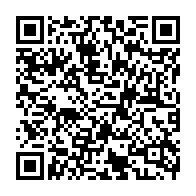

In [7]:

# Ejemplo de uso:
generar_qr("https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/2_diagnostico/diagnos_prueba_inicial_pivu/49_.ipynb")



In [11]:
import pandas as pd
from random import choice

def estudiante_que_va_a_participar(ruta_archivo):
    try:
        # skiprows=2 hace que la lectura comience en la fila 3 del Excel
        # La fila 3 pasará a ser el encabezado (donde debe estar 'NOMBRES Y APELLIDOS')
        df = pd.read_excel(ruta_archivo, sheet_name=0, skiprows=2)
    except Exception as e:
        return f"Error al abrir el archivo: {e}"

    # Verificamos que la columna exista después del salto de filas
    if 'NOMBRES Y APELLIDOS' not in df.columns:
        return "Error: No se encontró la columna 'NOMBRES Y APELLIDOS' a partir de la fila 3."

    lista_estudiantes = df['NOMBRES Y APELLIDOS'].dropna().tolist()

    if lista_estudiantes:
        estudiante = choice(lista_estudiantes)
        print(f"El estudiante seleccionado es: {estudiante}")
        return estudiante
    else:
        print('Todos los estudiantes han participado o la lista está vacía.')
        return None
    
# Ruta del archivo
ruta = r"C:\Users\marco\Documentos\extension\camino-udea\9_asistencia_evaluacion\pivu_caucasia_notas_quices.xlsx"
estudiante_que_va_a_participar(ruta)

El estudiante seleccionado es: Paola Andrea  Soto Montes 


'Paola Andrea  Soto Montes '

Este es un problema de **razonamiento lógico de ordenamiento lineal**. 

Para resolverlo, debemos organizar la información jerárquicamente basándonos en las restricciones de los pisos.



## Transcripción y Edición del Problema

**Enunciado:**
49. En cada uno de los cinco pisos de un edificio vive una familia diferente. Se sabe que:
* Los **Díaz** viven en el tercero.
* La familia **Abad** vive más abajo que los **Estrada** y que los **Botero**.
* Los **Correa** viven más abajo que los **Abad**.

**Pregunta:**
La familia que vive en el segundo piso es:
(A) Abad
(B) Correa
(C) Botero
(D) Estrada

---



## Resolución Didáctica

Vamos a representar el edificio como un conjunto de pisos $P = \{1, 2, 3, 4, 5\}$.

### 1. Ubicación fija
El dato más sólido es el primero:
$$P_3 = \text{Díaz}$$



### 2. Análisis de las relaciones de orden
Tenemos las siguientes desigualdades de posición (donde un número menor indica un piso más bajo):
1.  $Abad < Estrada$
2.  $Abad < Botero$
3.  $Correa < Abad$

Combinando las desigualdades (2) y (3), obtenemos una cadena lógica:
$$Correa < Abad < \{Estrada, Botero\}$$



### 3. Deducción de posiciones
* Como hay 5 pisos y los Díaz ocupan el **Piso 3**, quedan libres los pisos $\{1, 2\}$ y $\{4, 5\}$.
* La cadena $Correa < Abad$ requiere **dos espacios consecutivos** por debajo de alguien o en los niveles inferiores. 
* Si $Abad$ viviera en el piso 4 o 5, no podría haber dos familias (*Estrada* y *Botero*) por encima de ella, ya que solo quedaría un piso disponible (el 4 o el 5) y el 3 ya está ocupado.
* Por lo tanto, la cadena $Correa < Abad$ debe ocupar obligatoriamente los pisos por debajo del tercero:
    * **Piso 1:** Correa (el que vive más abajo de todos).
    * **Piso 2:** Abad.



Esto deja los pisos 4 y 5 para los Estrada y los Botero (en cualquier orden, pues el problema no especifica cuál de los dos está más arriba).

**Respuesta Correcta:** La familia que vive en el segundo piso es la familia **Abad**. La opción correcta es la **(A)**.




## Representación de Datos y Visualización


### Tabla de Posiciones (Pandas)

Utilizamos **Pandas** para mostrar la estructura final del edificio.


In [12]:
import pandas as pd

edificio = pd.DataFrame({
    'Piso': [5, 4, 3, 2, 1],
    'Familia': ['Estrada / Botero', 'Botero / Estrada', 'Díaz', 'Abad', 'Correa']
})

print(edificio.to_string(index=False))


 Piso          Familia
    5 Estrada / Botero
    4 Botero / Estrada
    3             Díaz
    2             Abad
    1           Correa


### Visualización con Matplotlib

Representamos el edificio de forma gráfica para visualizar el ordenamiento.



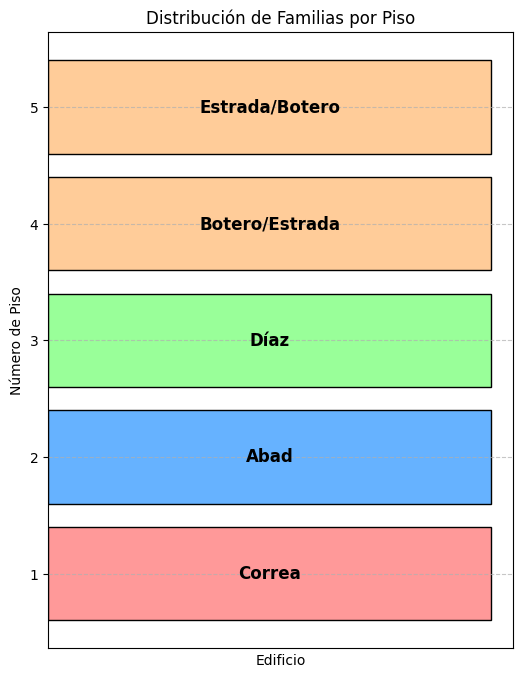

In [13]:
import matplotlib.pyplot as plt

pisos = [1, 2, 3, 4, 5]
familias = ['Correa', 'Abad', 'Díaz', 'Botero/Estrada', 'Estrada/Botero']
colores = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FFCC99']

plt.figure(figsize=(6, 8))
plt.barh(pisos, [1]*5, color=colores, edgecolor='black', height=0.8)

for i, familia in enumerate(familias):
    plt.text(0.5, i+1, familia, ha='center', va='center', fontsize=12, fontweight='bold')

plt.title('Distribución de Familias por Piso')
plt.xlabel('Edificio')
plt.ylabel('Número de Piso')
plt.xticks([])
plt.yticks(pisos)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("C:\\Users\\marco\\Downloads\\edificio_familias.png", bbox_inches='tight')
plt.show()


### Interactividad con Plotly



In [14]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Table(
    header=dict(values=['Piso', 'Familia'],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[[5, 4, 3, 2, 1], 
                       ['Estrada/Botero', 'Botero/Estrada', 'Díaz', 'Abad', 'Correa']],
               fill_color='lavender',
               align='left'))
])

fig.update_layout(title="Resumen Lógico: Ocupación del Edificio")
fig.show()
fig.write_image("C:\\Users\\marco\\Downloads\\resumen_logico_edificio.png")


> **Conclusión Lógica:** La clave es notar que la familia Abad tiene a alguien por debajo (*Correa*) y a dos familias por encima (*Estrada y Botero*). Dado que el piso 3 está ocupado, la única forma de que Abad tenga a alguien abajo es ocupando el **Piso 2**.

[Video de apoyo a la presenttación del ejercicio 49 del diagnóstico]()

In [10]:
78-41+1

38